## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sunpy.net import Fido, attrs as a
import astropy.units as u

from datetime import timedelta

import logging

import os

## 2. Check existing flares

In [2]:
# Primero, ver TODAS las columnas disponibles
result_hek = Fido.search(
    a.Time("2023-08-01", "2023-12-01"),
    a.hek.FL,
    a.hek.FRM.Name == "SWPC"
)
hek_table = result_hek["hek"]

# Filtrar columnas unidimensionales
names = [name for name in hek_table.colnames if len(hek_table[name].shape) <= 1]
hek_1d = hek_table[names]

# Convertir a DataFrame de pandas
df_hek = hek_1d.to_pandas()
# Filtrar tabla: solo flares de clase M o superior (M, X)
df_filtered = df_hek[df_hek['fl_goescls'].apply(lambda x: x[0] in ['X'])]

print(f"Total de flares en rango: {len(df_hek)}")
print(f"Flares de clase X: {len(df_filtered)}\n")


Total de flares en rango: 808
Flares de clase X: 2



In [3]:
goes_mission_number = 18

# Flujo completo: encontrar eventos con datos en ambos instrumentos
matched_events = []

for i, (idx, row) in enumerate(df_filtered.iterrows()):
    flare_time = row['event_peaktime']
    ar_num = row['ar_noaanum']
    goes_class = row['fl_goescls']
    start_time = row['event_starttime']
    end_time = row['event_endtime']
    
    # Ventana de ±15 minutos alrededor del flare
    t_start = flare_time - timedelta(minutes=15)
    t_end = flare_time + timedelta(minutes=15)
    
    print(f"\n--- Flare {i+1}: {flare_time} | GOES {goes_class} | AR {ar_num} ---")
    
    # Buscar AIA
    try:
        aia_result = Fido.search(
            a.Time(str(t_start), str(t_end)),
            a.Instrument('AIA'),
            a.Level.one,
            a.Wavelength(304*u.Angstrom)
        )
        aia_count = len(aia_result['vso']) if 'vso' in aia_result.keys() else 0
        print(f"  AIA 304 Å: {aia_count} imágenes disponibles")
    except Exception as e:
        aia_count = 0
        print(f"  AIA 304 Å: ERROR")
    
    # Buscar SUVI
    try:
        suvi_result = Fido.search(
            a.Time(str(t_start), str(t_end)),
            a.Instrument('SUVI'),
            a.Level.two,
            a.Wavelength(304*u.Angstrom),
            a.goes.SatelliteNumber(goes_mission_number)
        )
        suvi_count = len(suvi_result) if len(suvi_result) > 0 else 0
        print(f"  SUVI 304 Å: {suvi_count} imágenes disponibles")
    except Exception as e:
        suvi_count = 0
        print(f"  SUVI 304 Å: ERROR")
    
    # Guardar si ambos tienen datos
    if aia_count > 0 and suvi_count > 0:
        matched_events.append({
            'peak_time': flare_time,
            'start_time': start_time,
            'end_time': end_time,
            'goes_class': goes_class,
            'ar_noaa': ar_num,
            'aia_images': aia_count,
            'suvi_images': suvi_count
        })
        print(f"  ✓ MATCH!")


--- Flare 1: 2023-08-05 22:21:00 | GOES X1.6 | AR 0 ---


  AIA 304 Å: 150 imágenes disponibles
  SUVI 304 Å: 1 imágenes disponibles
  ✓ MATCH!

--- Flare 2: 2023-08-07 20:46:00 | GOES X1.5 | AR 0 ---
  AIA 304 Å: 150 imágenes disponibles
  SUVI 304 Å: 1 imágenes disponibles
  ✓ MATCH!


In [4]:
# Convertir matched_events a DataFrame
df_matched = pd.DataFrame(matched_events)

if len(df_matched) == 0:
    print("\nNo se encontraron eventos M/X con datos en ambos instrumentos")
else:
    # Función para convertir clase GOES a valor numérico
    def goes_to_numeric(goes_string):
        letter_values = {'A': 1, 'B': 2, 'C': 3, 'M': 4, 'X': 5}
        letter = goes_string[0]
        number = float(goes_string[1:])
        return letter_values[letter] + number / 100
    
    # Ordenar por clase GOES (más fuerte primero)
    df_matched['goes_numeric'] = df_matched['goes_class'].apply(goes_to_numeric)
    strongest_flare = df_matched.loc[df_matched['goes_numeric'].idxmax()]
    
    print(f"\n{'='*60}")
    print(f"EVENTO MÁS FUERTE (M o superior) CON DATOS EN AMBOS")
    print(f"{'='*60}")
    print(f"Flare: {strongest_flare['peak_time']}")
    print(f"  Clase GOES: {strongest_flare['goes_class']}")
    print(f"  AR NOAA: {strongest_flare['ar_noaa']}")
    print(f"  AIA imágenes: {strongest_flare['aia_images']}")
    print(f"  SUVI imágenes: {strongest_flare['suvi_images']}")


EVENTO MÁS FUERTE (M o superior) CON DATOS EN AMBOS
Flare: 2023-08-05 22:21:00
  Clase GOES: X1.6
  AR NOAA: 0
  AIA imágenes: 150
  SUVI imágenes: 1


## 3. Download observations

In [ ]:
def descargar_si_no_existe(fido_search, instrumento, path):
    """Descarga solo si no existen archivos locales"""
    os.makedirs(path, exist_ok=True)
    archivos_locales = [f for f in os.listdir(path) if f.endswith('.fits')]
    
    if len(archivos_locales) > 0:
        print(f"✓ {instrumento}: {len(archivos_locales)} archivos ya descargados")
        return sorted([os.path.join(path, f) for f in archivos_locales])
    else:
        print(f"Descargando {instrumento}...")
        files = Fido.fetch(fido_search, path=path)
        print(f"✓ Descargados {len(files)} archivos {instrumento}")
        return files

# Crear directorios
os.makedirs("./data/aia/", exist_ok=True)
os.makedirs("./data/suvi/", exist_ok=True)

start_time = strongest_flare['start_time']
end_time = strongest_flare['end_time']

print(f"Evento más fuerte: {strongest_flare['peak_time']} | GOES {strongest_flare['goes_class']}\n")

# Buscar SUVI en toda la ventana del flare
print("Buscando SUVI 304 Å...")
suvi_search = Fido.search(
    a.Time(str(start_time), str(end_time)),
    a.Instrument('SUVI'),
    a.Level.two,
    a.Wavelength(304*u.Angstrom),
    a.goes.SatelliteNumber(goes_mission_number)
)

if len(suvi_search) > 0:
    suvi_files = descargar_si_no_existe(suvi_search, "SUVI 304 Å", "./data/suvi/")
    print()
else:
    print("ERROR: No se encontraron imágenes SUVI")
    suvi_files = []

# Buscar AIA en la MISMA ventana del flare (no anclado a un solo timestamp SUVI)
print("Buscando AIA 304 Å (misma ventana temporal que SUVI)...")
aia_search = Fido.search(
    a.Time(str(start_time), str(end_time)),
    a.Instrument('AIA'),
    a.Level.one,
    a.Wavelength(304*u.Angstrom)
)

if 'vso' in aia_search.keys() and len(aia_search['vso']) > 0:
    aia_files = descargar_si_no_existe(aia_search['vso'], "AIA 304 Å", "./data/aia/")
else:
    print("ERROR: No se encontraron imágenes AIA")
    aia_files = []

print("\n✓ Descarga completada")

Evento más fuerte: 2023-08-05 22:21:00 | GOES X1.6

Buscando SUVI 304 Å...


Descargando SUVI 304 Å...


Files Downloaded:   0%|          | 0/15 [00:00<?, ?file/s]

dr_suvi-l2-ci304_g18_s20230805T215200Z_e20230805T215600Z_v1-0-2.fits:   0%|          | 0.00/1.85M [00:00<?, ?B…

dr_suvi-l2-ci304_g18_s20230805T220000Z_e20230805T220400Z_v1-0-2.fits:   0%|          | 0.00/1.85M [00:00<?, ?B…

...

aia.lev1.304A_2023_08_05T21_56_41.13Z.image_lev1.fits:   0%|          | 0.00/7.59M [00:00<?, ?B/s]

aia.lev1.304A_2023_08_05T21_57_29.13Z.image_lev1.fits:   0%|          | 0.00/7.59M [00:00<?, ?B/s]

aia.lev1.304A_2023_08_05T21_56_53.13Z.image_lev1.fits:   0%|          | 0.00/7.59M [00:00<?, ?B/s]

aia.lev1.304A_2023_08_05T21_57_41.13Z.image_lev1.fits:   0%|          | 0.00/7.59M [00:00<?, ?B/s]

aia.lev1.304A_2023_08_05T21_57_17.13Z.image_lev1.fits:   0%|          | 0.00/7.59M [00:00<?, ?B/s]

## 4. Plot de AIA y SUVI

Peak time del flare: 2023-08-05 22:21:00

SUVI más cercano: dr_suvi-l2-ci304_g18_s20230805T214800Z_e20230805T215200Z_v1-0-2.fits
  Diferencia: 16083.4 segundos

AIA más cercano: aia.lev1.304A_2023_08_05T21_48_05.13Z.image_lev1.fits
  Diferencia: 16025.1 segundos



SUVI:
  Shape: (1280, 1280)
  Min: -1.8733112812042236
  Max: 243.3990478515625
  Mean: 3.17988920211792
  Std: 6.603318214416504
  Timestamp: 2023-08-05T21:49:03.355

AIA:
  Shape: (4096, 4096)
  Min: -8.0
  Max: 1636.0
  Mean: 7.556199550628662
  Std: 11.922744750976562
  Timestamp: 2023-08-05T21:48:05.13



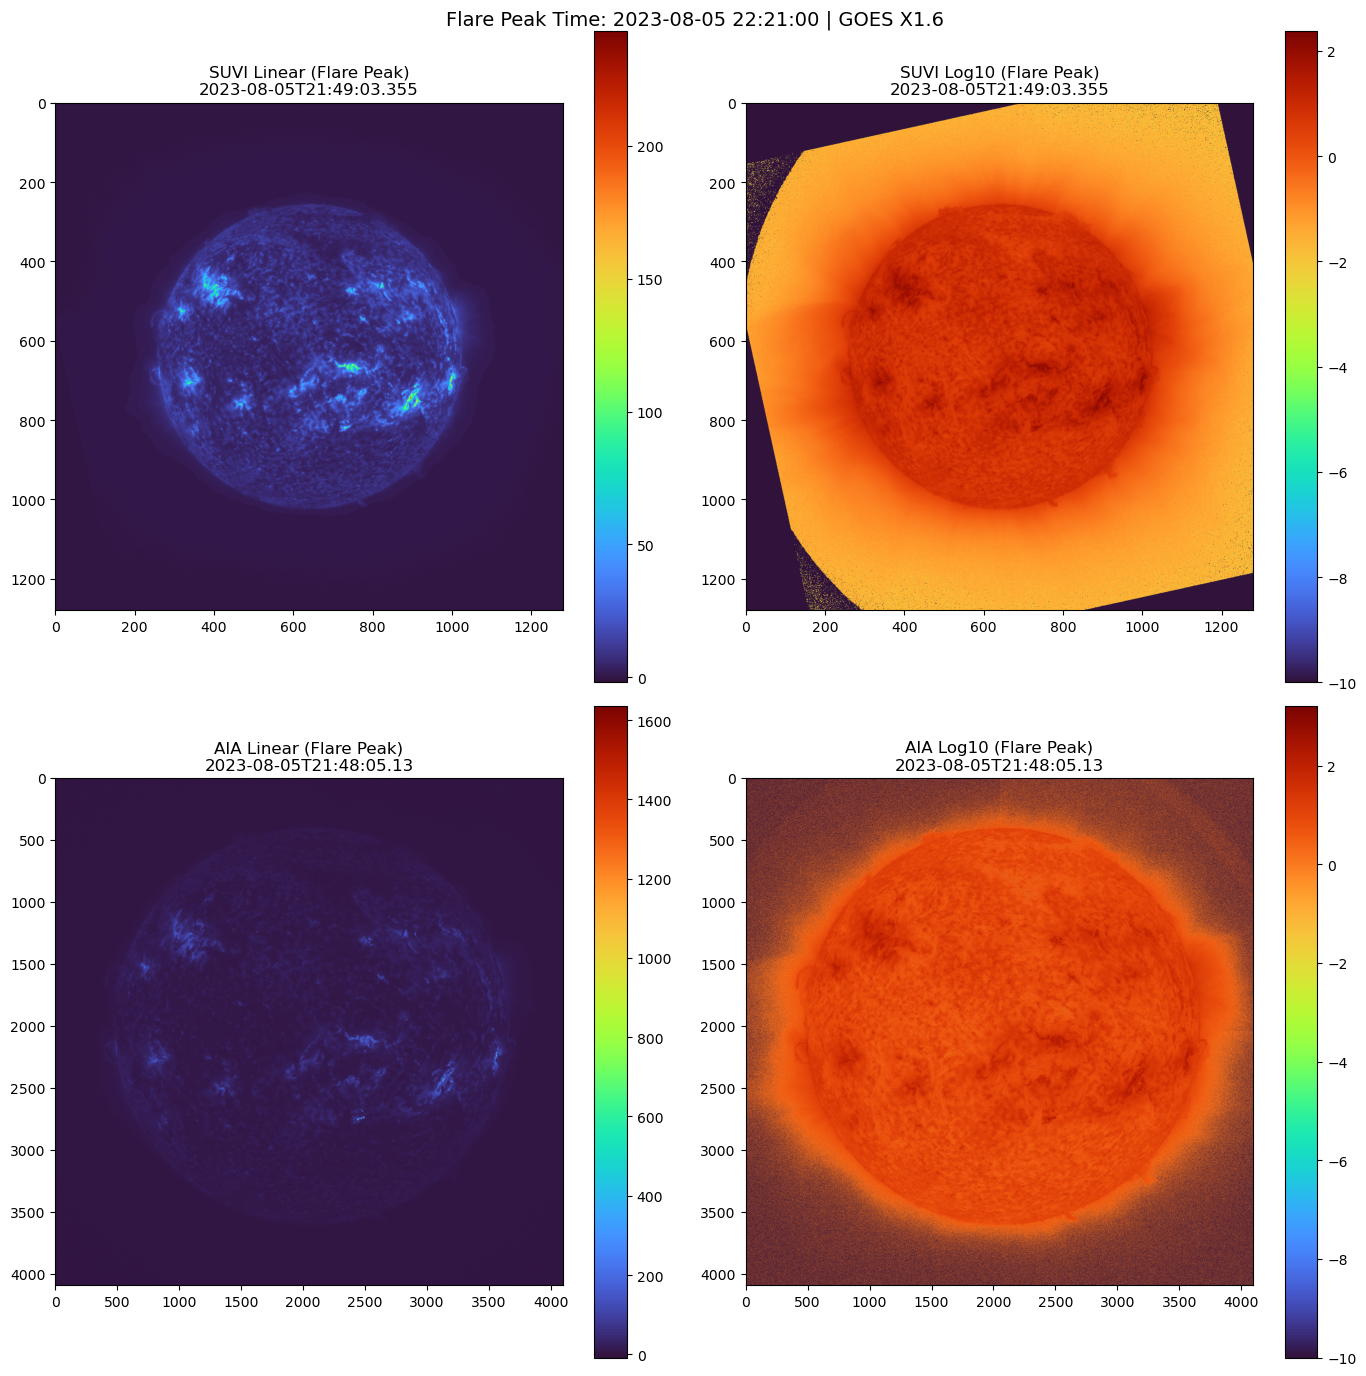

✓ Guardado: debug_suvi_aia_peak.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import os
from datetime import datetime

def obtener_timestamp(fits_file):
    """Extrae DATE-OBS del archivo FITS"""
    with fits.open(fits_file) as hdul:
        return hdul[1].header['DATE-OBS']

def tiempo_a_segundos(timestamp_str):
    dt = datetime.fromisoformat(timestamp_str.replace('Z', '+00:00'))
    return dt.timestamp()

# Timestamp del peak del flare
peak_time = strongest_flare['peak_time']
peak_segundos = pd.Timestamp(peak_time).timestamp()

print(f"Peak time del flare: {peak_time}\n")

# Listar archivos
suvi_files = sorted([f for f in os.listdir('./data/suvi/') if f.endswith('.fits')])
aia_files = sorted([f for f in os.listdir('./data/aia/') if f.endswith('.fits')])

# Encontrar SUVI más cercano al peak
suvi_diffs = []
for f in suvi_files:
    ts = obtener_timestamp(f'./data/suvi/{f}')
    seg = tiempo_a_segundos(ts)
    suvi_diffs.append(abs(seg - peak_segundos))

suvi_closest_idx = np.argmin(suvi_diffs)
suvi_closest_file = suvi_files[suvi_closest_idx]

# Encontrar AIA más cercano al peak
aia_diffs = []
for f in aia_files:
    ts = obtener_timestamp(f'./data/aia/{f}')
    seg = tiempo_a_segundos(ts)
    aia_diffs.append(abs(seg - peak_segundos))

aia_closest_idx = np.argmin(aia_diffs)
aia_closest_file = aia_files[aia_closest_idx]

print(f"SUVI más cercano: {suvi_closest_file}")
print(f"  Diferencia: {suvi_diffs[suvi_closest_idx]:.1f} segundos\n")

print(f"AIA más cercano: {aia_closest_file}")
print(f"  Diferencia: {aia_diffs[aia_closest_idx]:.1f} segundos\n")

# Leer imágenes
with fits.open(f'./data/suvi/{suvi_closest_file}') as hdul:
    suvi_img = hdul[1].data
    suvi_ts = hdul[1].header['DATE-OBS']

with fits.open(f'./data/aia/{aia_closest_file}') as hdul:
    aia_img = hdul[1].data
    aia_ts = hdul[1].header['DATE-OBS']

# Información de datos
print("SUVI:")
print(f"  Shape: {suvi_img.shape}")
print(f"  Min: {np.nanmin(suvi_img)}")
print(f"  Max: {np.nanmax(suvi_img)}")
print(f"  Mean: {np.nanmean(suvi_img)}")
print(f"  Std: {np.nanstd(suvi_img)}")
print(f"  Timestamp: {suvi_ts}\n")

print("AIA:")
print(f"  Shape: {aia_img.shape}")
print(f"  Min: {np.nanmin(aia_img)}")
print(f"  Max: {np.nanmax(aia_img)}")
print(f"  Mean: {np.nanmean(aia_img)}")
print(f"  Std: {np.nanstd(aia_img)}")
print(f"  Timestamp: {aia_ts}\n")

# Plot lado a lado con diferentes normalizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# SUVI - linear
ax = axes[0, 0]
im = ax.imshow(suvi_img, cmap='turbo')
ax.set_title(f'SUVI Linear (Flare Peak)\n{suvi_ts}')
plt.colorbar(im, ax=ax)

# SUVI - log
ax = axes[0, 1]
suvi_log = np.log10(np.clip(suvi_img, 1e-10, None))
im = ax.imshow(suvi_log, cmap='turbo')
ax.set_title(f'SUVI Log10 (Flare Peak)\n{suvi_ts}')
plt.colorbar(im, ax=ax)

# AIA - linear
ax = axes[1, 0]
im = ax.imshow(aia_img, cmap='turbo')
ax.set_title(f'AIA Linear (Flare Peak)\n{aia_ts}')
plt.colorbar(im, ax=ax)

# AIA - log
ax = axes[1, 1]
aia_log = np.log10(np.clip(aia_img, 1e-10, None))
im = ax.imshow(aia_log, cmap='turbo')
ax.set_title(f'AIA Log10 (Flare Peak)\n{aia_ts}')
plt.colorbar(im, ax=ax)

plt.suptitle(f'Flare Peak Time: {peak_time} | GOES {strongest_flare["goes_class"]}', fontsize=14)
plt.tight_layout()
plt.savefig('debug_suvi_aia_peak.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Guardado: debug_suvi_aia_peak.png")

## 5. Video de las imágenes descargadas

In [ ]:
import cv2
import numpy as np
from astropy.io import fits
import os
from datetime import datetime

def normalizar_debug(img):
    img = np.asarray(img, dtype=np.float32)
    img[img <= 0] = 1
    img_log = np.log10(img)
    
    vmin = np.nanpercentile(img_log, 2)
    vmax = np.nanpercentile(img_log, 98)
    
    img_norm = (img_log - vmin) / (vmax - vmin + 1e-10)
    img_norm = np.clip(img_norm, 0, 1) * 255
    
    return img_norm.astype(np.uint8)

def obtener_timestamp(fits_file):
    with fits.open(fits_file) as hdul:
        if 'COMPRESSED_IMAGE' in [hdu.name for hdu in hdul]:
            return hdul[1].header['DATE-OBS']
        else:
            return hdul[0].header['DATE-OBS']

def tiempo_a_segundos(timestamp_str):
    dt = datetime.fromisoformat(timestamp_str.replace('Z', '+00:00'))
    return dt.timestamp()

# Listar archivos
suvi_files = sorted([f for f in os.listdir('./data/suvi/') if f.endswith('.fits')])
aia_files = sorted([f for f in os.listdir('./data/aia/') if f.endswith('.fits')])

print(f"SUVI: {len(suvi_files)} archivos")
print(f"AIA: {len(aia_files)} archivos")

# Extraer timestamps y ORDENAR cronológicamente por tiempo real (no por nombre de archivo)
suvi_data = []
for f in suvi_files:
    ts = obtener_timestamp(f'./data/suvi/{f}')
    suvi_data.append({'file': f, 'timestamp': ts, 'segundos': tiempo_a_segundos(ts)})
suvi_data.sort(key=lambda x: x['segundos'])

aia_data = []
for f in aia_files:
    ts = obtener_timestamp(f'./data/aia/{f}')
    aia_data.append({'file': f, 'timestamp': ts, 'segundos': tiempo_a_segundos(ts)})
aia_data.sort(key=lambda x: x['segundos'])

# Crear video: AIA avanza frame a frame, SUVI se mantiene fijo
# y solo avanza cuando AIA está más cerca del siguiente frame de SUVI
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('./video_suvi_aia_interleaved.mp4', fourcc, 10.0, (2560, 1280))

suvi_idx = 0  # Índice del frame de SUVI actualmente "sostenido"

print("\nGenerando frames...")
for i, aia_frame in enumerate(aia_data):
    print(f"AIA frame {i+1}/{len(aia_data)}...", end='\r')
    
    aia_seg = aia_frame['segundos']
    
    # Avanzar SUVI mientras el siguiente frame de SUVI esté más cerca del tiempo actual de AIA
    while suvi_idx < len(suvi_data) - 1:
        dist_actual = abs(aia_seg - suvi_data[suvi_idx]['segundos'])
        dist_siguiente = abs(aia_seg - suvi_data[suvi_idx + 1]['segundos'])
        if dist_siguiente < dist_actual:
            suvi_idx += 1
        else:
            break
    
    suvi_frame = suvi_data[suvi_idx]
    
    # Leer imagen SUVI (la que está actualmente "sostenida")
    with fits.open(f'./data/suvi/{suvi_frame["file"]}') as hdul:
        suvi_img = hdul[1].data
    
    # Leer imagen AIA (avanzando)
    with fits.open(f'./data/aia/{aia_frame["file"]}') as hdul:
        aia_img = hdul[1].data
    
    # Normalizar
    suvi_gray = normalizar_debug(suvi_img)
    aia_gray = normalizar_debug(aia_img)
    
    # Redimensionar AIA a 1280x1280
    aia_gray = cv2.resize(aia_gray, (1280, 1280))
    
    # Convertir a BGR
    suvi_bgr = cv2.cvtColor(suvi_gray, cv2.COLOR_GRAY2BGR)
    aia_bgr = cv2.cvtColor(aia_gray, cv2.COLOR_GRAY2BGR)
    
    # Juntar lado a lado
    frame = np.hstack([suvi_bgr, aia_bgr])
    
    # Añadir timestamps
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(frame, f'SUVI: {suvi_frame["timestamp"]}', (50, 50), font, 1, (255, 255, 255), 2)
    cv2.putText(frame, f'AIA: {aia_frame["timestamp"]}', (1330, 50), font, 1, (255, 255, 255), 2)
    
    diff_seg = abs(aia_seg - suvi_frame['segundos'])
    cv2.putText(frame, f'Diff: {diff_seg:.1f}s', (900, 1200), font, 1.5, (0, 255, 255), 3)
    cv2.putText(frame, f'SUVI frame {suvi_idx+1}/{len(suvi_data)}', (50, 1200), font, 1, (0, 255, 0), 2)
    
    out.write(frame.astype(np.uint8))

out.release()
print(f"\n✓ Video guardado: ./video_suvi_aia_interleaved.mp4 ({len(aia_data)} frames totales)")

SUVI: 15 archivos
AIA: 10 archivos
Tiempo SUVI
2023-08-05T21:49:03.355
Tiempo SUVI
2023-08-05T21:53:03.349
Tiempo SUVI
2023-08-05T21:57:03.377
Tiempo SUVI
2023-08-05T22:01:03.389
Tiempo SUVI
2023-08-05T22:05:03.399
Tiempo SUVI
2023-08-05T22:09:03.411
Tiempo SUVI
2023-08-05T22:13:03.423
Tiempo SUVI
2023-08-05T22:17:03.435
Tiempo SUVI
2023-08-05T22:21:03.445
Tiempo SUVI
2023-08-05T22:25:03.457
Tiempo SUVI
2023-08-05T22:29:03.469
Tiempo SUVI
2023-08-05T22:33:03.479
Tiempo SUVI
2023-08-05T22:37:03.491
Tiempo SUVI
2023-08-05T22:41:03.503
Tiempo SUVI
2023-08-05T22:45:03.515
Tiempo AIA
2023-08-05T21:48:05.13
Tiempo AIA
2023-08-05T21:48:17.13
Tiempo AIA
2023-08-05T21:48:29.14
Tiempo AIA
2023-08-05T21:48:41.13
Tiempo AIA
2023-08-05T21:48:53.13
Tiempo AIA
2023-08-05T21:49:05.13
Tiempo AIA
2023-08-05T21:49:17.13
Tiempo AIA
2023-08-05T21:49:29.13
Tiempo AIA
2023-08-05T21:49:41.13
Tiempo AIA
2023-08-05T21:49:53.13

Generando frames...


OpenCV: FFMPEG: tag 0x44495658/'XVID' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


Frame 15/15...
✓ Video guardado: ./video_suvi_aia.mp4
